## Lab 1 Part A: OOP Search Algorithms for Drone Pathfinding


### Setup and Imports


In [75]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

### 2.Abstract Problem Interface


In [76]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

### 3.The Node Class


In [77]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

### 4. Helper Functions


In [78]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

### 5. Implementing the Grid Search Problem


In [79]:
MOVES = {"UP": (-1, 0), "DOWN": (1, 0), "LEFT": (0, -1), "RIGHT": (0, 1)}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        if state == self.goal:
            return True
        else:
            return False
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> List[str]:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:

        legal_actions = []
        for legal_action in MOVES:
            row, col = state
            change_row, change_col = MOVES[legal_action]

            neighbour = (row + change_row, col + change_col)

            if self.in_bounds(neighbour) and self.is_free(neighbour) == True:
                legal_actions.append(legal_action)
        return legal_actions
        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        dr, dc = MOVES[action]
        row, col = state
        return (row + dr, col + dc)
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self, state: Tuple[int, int], action: str, next_state: Tuple[int, int]
    ) -> float:
        return 1


### 5.1 Self-Check for GridProblem


In [80]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


### 6. Sample Drone Map


In [81]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

### 7.Visualisation Helper


In [82]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

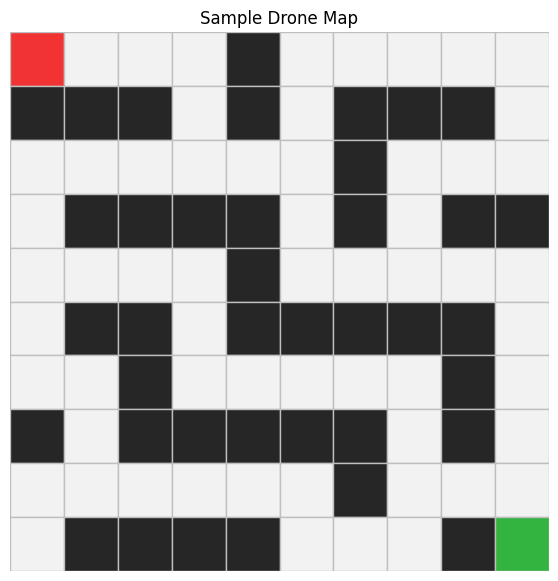

In [83]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

### 8. The Shared expand Method


In [84]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        s = node.state

        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)

            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

### 9. Breadth-First Search (BFS)


In [85]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        node = Node(problem.initial_state())
        nodes_expanded = 0
        max_frontier = 1

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier,
                reached_count=1,
            )

        frontier = deque([node])
        reached = {problem.initial_state()}

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                s = child.state

                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier,
                        reached_count=len(reached),
                    )

                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
                    max_frontier = max(max_frontier, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier,
            reached_count=len(reached),
        )

### 10. Depth-First Search (DFS)

In [86]:
class DepthFirstSearch(SearchAlgorithm):
  def search(self, problem: Problem) -> SearchResult:
    algorithm = "DFS"

    node = Node(problem.initial_state())
    nodes_expanded = 0
    max_frontier = 1

    if problem.is_goal(node.state):
      return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier,
                reached_count=1,
            )

    frontier_stack = [node]
    reached = {problem.initial_state()}

    while frontier_stack:
      node = frontier_stack.pop()
      nodes_expanded +=1

      for child in self.expand(problem,node):
        s = child.state

        if (problem.is_goal(s)):
           return SearchResult(
             algorithm=algorithm,
             status="success",
             solution=child,
             nodes_expanded=nodes_expanded,max_frontier_size=max_frontier,
             reached_count=len(reached),
            )
        if s not in reached:
          reached.add(s)
          frontier_stack.append(child)
          max_frontier = max(
            max_frontier,
            len(frontier_stack)
            )
    return SearchResult(
             algorithm=algorithm,
             status="failure",
             solution=None,
             nodes_expanded=nodes_expanded,max_frontier_size=max_frontier,
             reached_count=len(reached),
            )


  ### 11. Depth-Limited Search(DLS)

In [87]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )
    def _recursive_dls(
            self,
            problem: Problem,
            node: Node,
            limit: int,
            metrics: Dict[str, int],
            current_stack_size: int,
            ) -> Tuple[Optional[Node], str]:
        if problem.is_goal(node.state):
            return (node, "success")
        elif node.depth >= limit:
            return (None, "cutoff")
        else:
            metrics["nodes_expanded"] += 1
            cutoff_occurred = False

        for child in self.expand(problem, node):

            if state_is_on_path(node, child.state):
                continue

            metrics["max_stack_size"] = max(
                metrics["max_stack_size"],
                current_stack_size + 1,
            )

            result, status = self._recursive_dls(
                problem=problem,
                node=child,
                limit=limit,
                metrics=metrics,
                current_stack_size=current_stack_size + 1,
            )

            if status == "success":
                return (result, "success")

            elif status == "cutoff":
                cutoff_occurred = True

        if cutoff_occurred:
            return (None, "cutoff")
        else:
            return (None, "failure")

### 12. Iterative Deep Learning (IDS)

In [88]:
class IterativeDeepeningSearch(SearchAlgorithm):
  def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
    algorithm = "IDS"
    iteration_log = []
    total_nodes_expanded = 0
    max_stack_size = 0

    for limit in range (0,max_depth+1):
      dls = DepthLimitedSearch()
      result = dls.search(problem, limit)
      iteration_log.append({"limit": limit, "status": result.status})
      total_nodes_expanded += result.nodes_expanded
      max_stack_size = max(max_stack_size, result.max_frontier_size)
      if result.status == "success":
        return SearchResult(
            algorithm="IDS",
            status="success",
            solution= result.solution,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size,
            limit=limit,
            iterations=iteration_log
        )
      elif result.status == "failure":
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size,
            reached_count=0,
            limit=limit,
        )
    return SearchResult(
      algorithm=algorithm,
      status="cutoff",
      solution=None,
      nodes_expanded=total_nodes_expanded,max_frontier_size=max_stack_size,
      reached_count=0,
      limit=max_depth,
      iterations=iteration_log,
      )
      
      



  
      


### 13. Run the Algorithms on the Sample Map

In [89]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,18.0,18.0,18,4,21
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,18.0,18.0,18.0,356,19,0


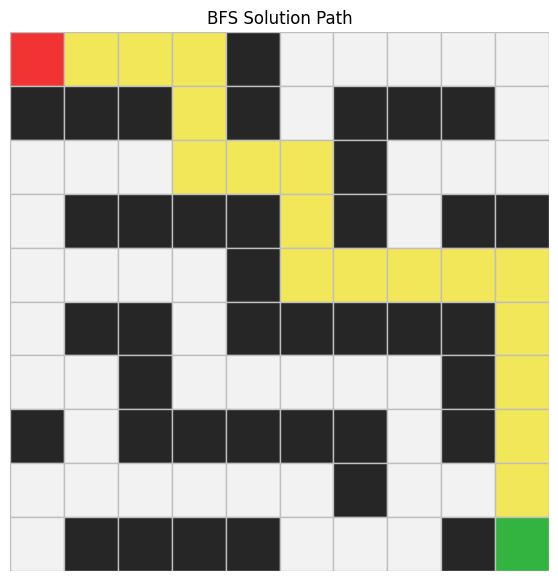

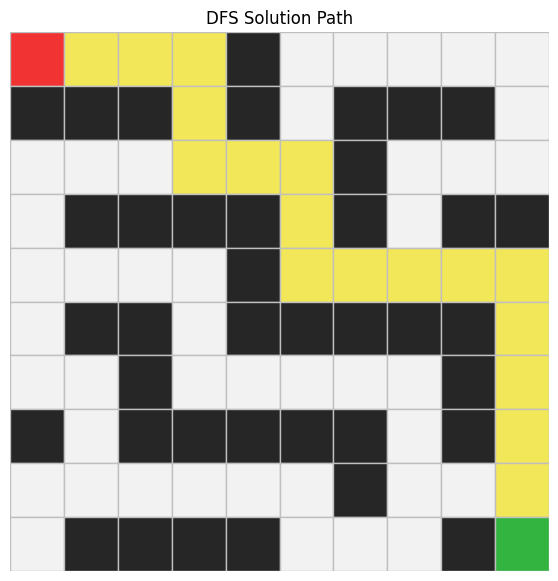

In [90]:
bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

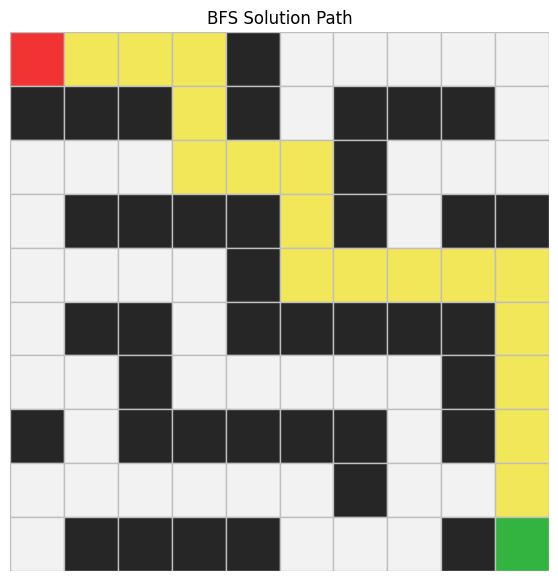

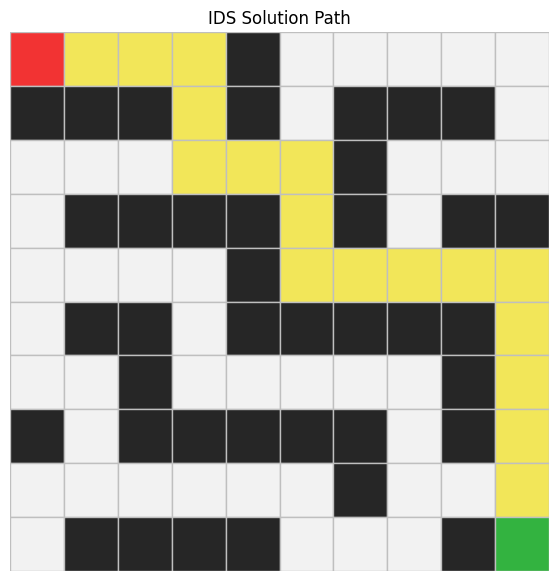

In [91]:
bfs_result = results[0]
ids_result = results[3]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=ids_result.path,
    title="IDS Solution Path",
)

### 14. Create Your Own Maps

In [92]:
custom_grid_1 = [
    [0,0,0,0,0,0,0,0,0,0],
    [1,1,1,1,1,1,1,1,1,0],
    [0,0,0,0,0,0,0,0,0,0],
]

custom_start_1 = (0,0)
custom_goal_1 = (2,9)

In [93]:
custom_grid_2 = [
    [0,0,1,0,0,0,1,0],
    [1,0,1,0,1,0,1,0],
    [0,0,0,0,1,0,0,0],
    [0,1,1,1,1,1,1,0],
    [0,0,0,0,0,0,0,0],
    [1,1,1,1,1,1,0,1],
    [0,0,0,0,0,0,0,0],
]

custom_start_2 = (0,0)
custom_goal_2 = (6,7)

In [94]:
custom_problem_1 = GridProblem(
    custom_grid_1,
    custom_start_1,
    custom_goal_1
)

custom_problem_2 = GridProblem(
    custom_grid_2,
    custom_start_2,
    custom_goal_2
)

In [95]:
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]

show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,11,11,11,1,11
1,DFS,success,NaN,11,11,11,1,11
2,DLS,success,20.0,11,11,11,12,0
3,IDS,success,11.0,11,11,66,12,0


In [96]:
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]

show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,15,15,26,3,29
1,DFS,success,NaN,19,19,26,4,29
2,DLS,success,20.0,15,15,20,21,0
3,IDS,success,15.0,15,15,176,16,0


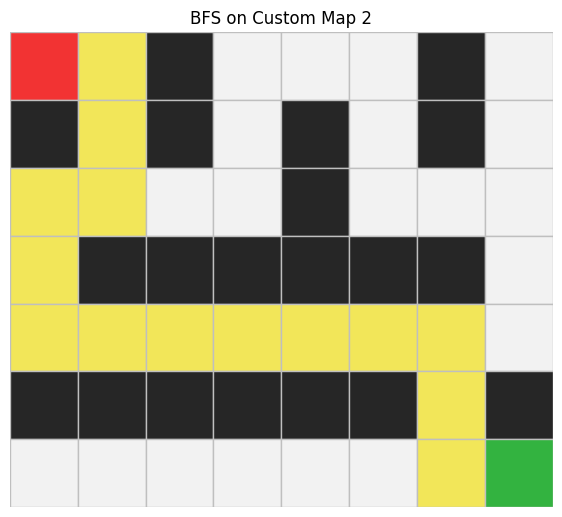

In [97]:
bfs_map= custom_results_2[0]

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=bfs_map2.path,
    title="BFS on Custom Map 2",
)

### 15. Reflection Questions

### 15.1 Problem Formulation
 1.The state in this lab is the current position of the drone on the grid.

 2. An action are the various moves the drone can make from one state to another. such as: up, down, left or right on the grid.

 3. The reuslt function returns the new state of the drone on the grid after performing an action on the current state. With regards to the lab, it takes the current position of the drone(row and column ) and  a Move, then returns the drone's new position on the grid.

 4.It is useful because the same search algorithm can solve different problems. The problem definiton helps describe the state, actions, result function, path_cost etc, while the search algortihm describes how to explore the state space. It makes the code reusable.


### 15.2 BFS
1. BFS uses a FIFO queue because it explores the nodes in the order they were discovered. The first node that was added to the frontier is the first one to be removed and explored or expanded. This allows BFS to explore all nodes at a level before moving to the next level.

2. This is becuase for BFS it explores states level by level. It visits all the states that are 1 step away from the start. The first time the BFS reaches the goal, it has found the path with the fewest number of steps.

3. The reached set keeps track of states that has already been discovered by the BFS. It prevents the search algorithm from revisiting the same state multiple times, which avoids cycles and limits redundancy.

### 15.3 DFS
1. DFS uses a stack because it uses the order LIFO. The node that was recently discovere is the first one that gets expanded. This allows the algorithm to go deeps as possible in one node along one path before exploring other path.

2. DFS is not guaranteed to find the shortest path.DFS explores one path as deeply as possible before exploring other paths. As a result, it may find a longer solution before discovering a shorter one.

3. DFS can use less memory than BFS when the tree has a large branching factor. The BFS must store the nodes in its frontier at the same time, while the DFS only needs to store the current path and the node which has not been explored yet.

4.DFS performs badly when there are many deep or misleading paths because it may explore them extensively before finding the goal or a shorter solution.

### 15.4 DLS
1. When the depth limit is too small, the algorithm is not able to search deeply enough to reach the goal. As a result it returns a "cutoff"status instead of a solution, even if a solution exists at a deeper level

2. The cutoff means the DLS algorithm stopped searching because it reached the lmit before finding a solution. it indicates a solution may still exist but it could be deeper than the given limit.

3. The DLS  is a modified version of DFS just that DLS has a depth limit. DLS stops searching once it reaches its maximum depth while the ordinary DFS keeps exploring deeper into nodes until it finds a goal or reaches a dead end.

4. Path-cycle checking is used to prevent the algorithm from revisiting states that is in the current path. It avoids infinte loops of the same state.

### 15.5 IDS
1.IDS repeats DLS with increasing limit so that it can eventually reach deeper levels of the search space. So when the depth is gradually increased.

2. This is because IDS it repeatedly the depth limit of DLS. Even if a small limit cannot reach the goal, the IDS will eventually use a large enough limit to find the solution if it exists

3. IDS uses less memory than BDS because it explores the search space in a depth-first way and only stores the current path while the BFS must store all nodes in the frontier at a given depth.

4. It rexpands the nodes alot of times. This increases the number of nodes needed to be expanded and computational work.

### 15.6 Real-World Drone Context
1. In a real drone application, one route may be safer or more practical than another because of environmental uncertainties and dynamic conditions such as obstacles, weather conditions etc. While a route with a lower path cost may save time and energy, but the safest route might not be always the fastest one.

2. BFS explores it level by level. Since all moves have the same cost, the first time BFS reaches the goal, it has found the path with the fewest number of moves. There BFS is optimal.

3.DLS because it allows us to set a maximum depth limit of the search. Once the limit is reached, the algorithm does not go beyond the depth.

4.  The grid model assumes the environment is static and known in advance whereas in the real-world drone navigation there is a dynamic environment with obstacles, environment thst is filled with uncertainties, such as weather conditions, sensor errors and a 3d movement. So the the grid model does not capture the complexities and constraints of a real world drone navigation.